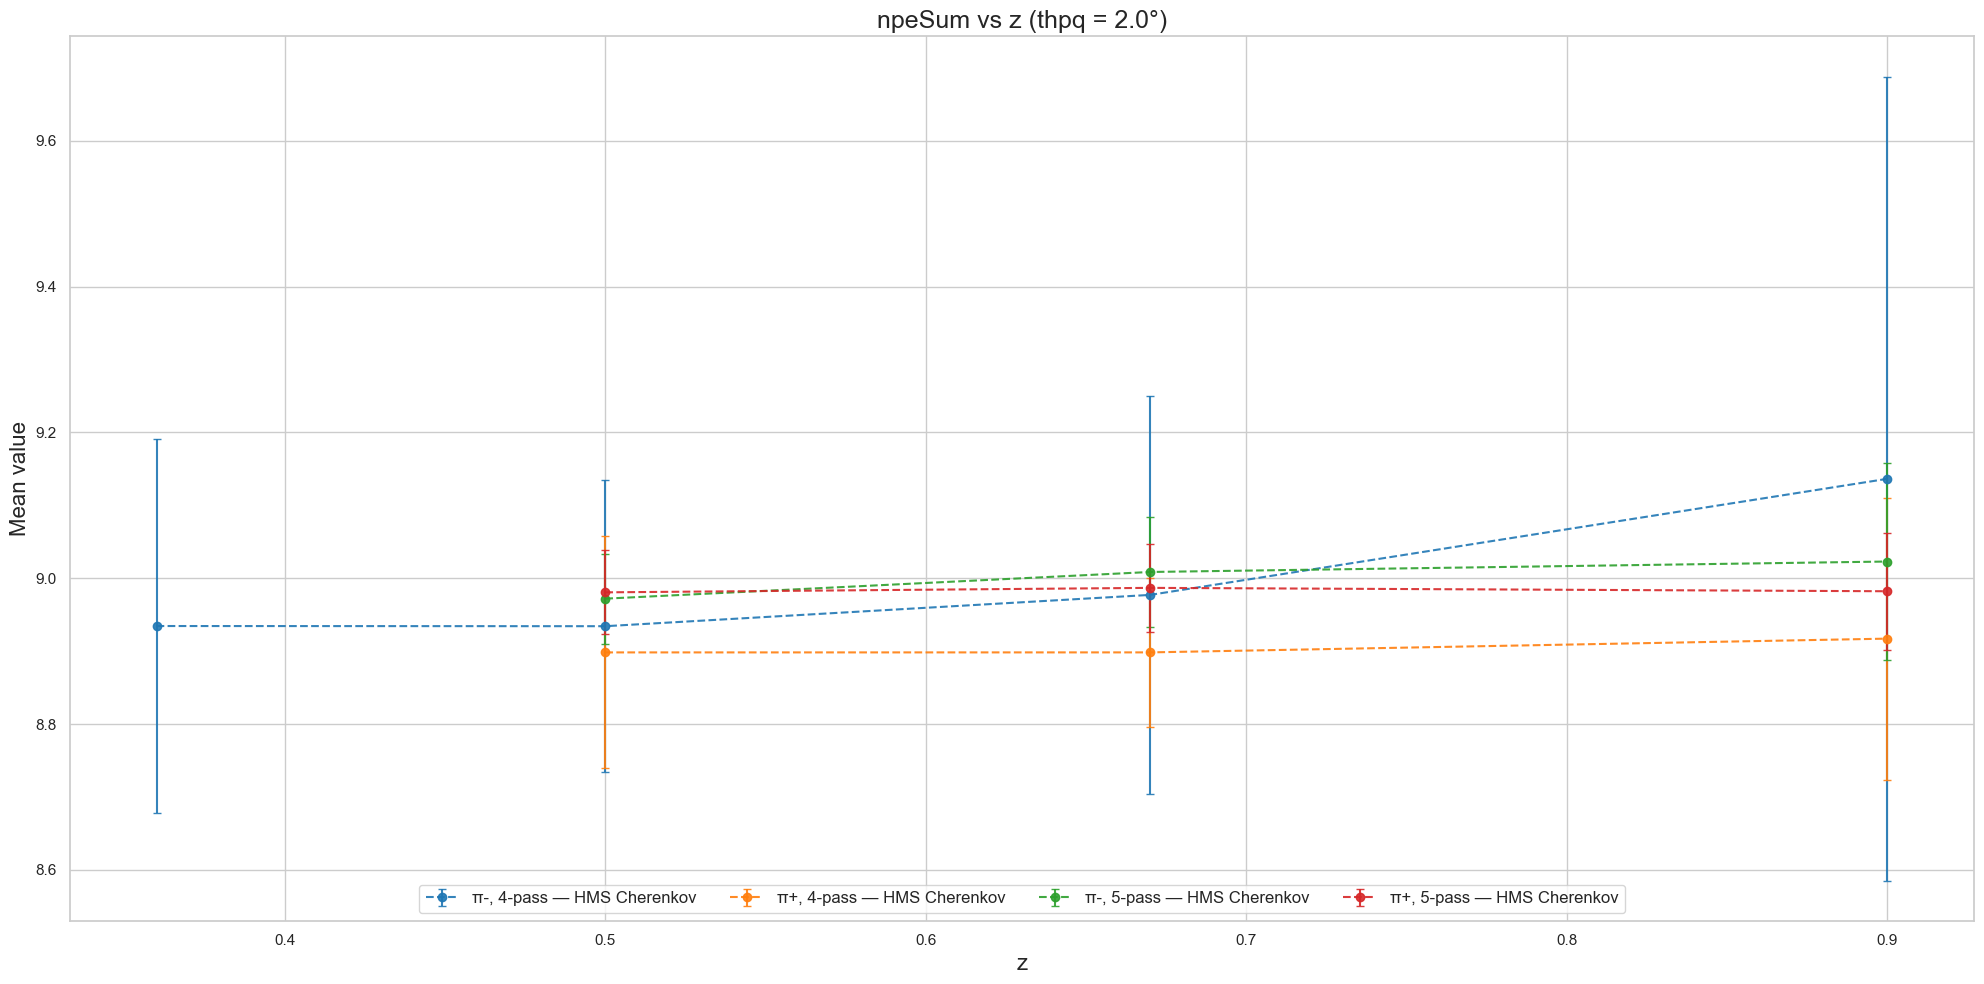

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import seaborn as sns

df = pd.read_csv("geometric_cut_means.csv")

# Only thpq = 2.0
df = df[df["thpq"] == 2.0]

detectors = {
    "HMS Cherenkov": ("H_cer_mean", "H_cer_std", "--"),
    # "Pion HG-Cherenkov": ("P_hgcer_mean", "P_hgcer_std", "--")
    # "Pion Aerogel": ("P_aero_mean", "P_aero_std", "--"),
}

settings = [
    ("π-, 4-pass", -1, 8.5831),
    ("π+, 4-pass", +1, 8.5831),
    ("π-, 5-pass", -1, 10.6716),
    ("π+, 5-pass", +1, 10.6716),
]

# ---------------------------------------------------
# Colors per setting
# ---------------------------------------------------
setting_colors = {
    "π-, 4-pass": "tab:blue",
    "π+, 4-pass": "tab:orange",
    "π-, 5-pass": "tab:green",
    "π+, 5-pass": "tab:red",
}

sns.set_theme(style="whitegrid")

# ---------------------------------------------------
# Plot
# ---------------------------------------------------
plt.figure(figsize=(20, 10))

for label, pol, ebeam in settings:
    subset = df[(df["polarity"] == pol) & (df["ebeam"] == ebeam) & (df["P_hgcer_mean"]>0) & (df["H_cer_mean"]>0) &  (df["P_aero_mean"]>0)].sort_values("z")
    color = setting_colors[label]

    for det_name, (mean_col, std_col, linestyle) in detectors.items():
        plt.errorbar(
            subset["z"],
            subset[mean_col],
            yerr=subset[std_col],
            label=f"{label} — {det_name}",
            color=color,
            linestyle=linestyle,
            marker="o",
            alpha=0.9,
            capsize=3,
        )

plt.xlabel("z", fontsize=16)
plt.ylabel("Mean value", fontsize=16)
plt.title("npeSum vs z (thpq = 2.0°)", fontsize=18)

plt.legend(fontsize=12, ncol=4, loc="lower center")
plt.tight_layout()
# plt.savefig("all_settings_meanz_singleplot.png", dpi=300)
plt.show()